In [13]:
import sys
sys.path.append('../src')

import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from torchvision import transforms
from model import build_model
from dataset import CheXpertDataset

# Load model
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = build_model()
model.load_state_dict(torch.load('../outputs/models/best_model.pth', map_location=device))
model.eval()
model = model.to(device)

# Load validation data
transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_dataset = CheXpertDataset('../data/archive/valid.csv', transform_val)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

# Load CSV with demographic information
val_df = pd.read_csv('../data/archive/valid.csv')

print(f"Model loaded on: {device}")
print(f"Validation patients: {len(val_df)}")

Model loaded on: mps
Validation patients: 234


In [14]:
# Get predictions
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = torch.sigmoid(model(images))
        all_preds.append(outputs.cpu().numpy())
        all_labels.append(labels.numpy())

all_preds = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

print(f"Predictions generated: {all_preds.shape}")

Predictions generated: (234, 5)


In [15]:
from sklearn.metrics import roc_auc_score

PATHOLOGIES = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Pleural Effusion']

print("AUC-ROC per pathology:")
print("-" * 35)
for i, pathology in enumerate(PATHOLOGIES):
    if all_labels[:, i].sum() > 0:
        auc = roc_auc_score(all_labels[:, i], all_preds[:, i])
        print(f"{pathology:<20} {auc:.4f}")
    else:
        print(f"{pathology:<20} N/A (no positive cases)")

AUC-ROC per pathology:
-----------------------------------
Atelectasis          0.7419
Cardiomegaly         0.8387
Consolidation        0.9255
Edema                0.9316
Pleural Effusion     0.9204


In [16]:
# Add demographics and predictions to dataframe
for i, pathology in enumerate(PATHOLOGIES):
    val_df[f'pred_{pathology}'] = all_preds[:, i]
    val_df[f'true_{pathology}'] = all_labels[:, i]

# AUC-ROC by sex
print("AUC-ROC by sex:")
print("-" * 50)
for pathology in PATHOLOGIES:
    print(f"\n{pathology}")
    for sex in ['Male', 'Female']:
        subset = val_df[val_df['Sex'] == sex]
        if subset[f'true_{pathology}'].sum() > 0:
            auc = roc_auc_score(subset[f'true_{pathology}'], subset[f'pred_{pathology}'])
            print(f"  {sex:<10} {auc:.4f}  (n={len(subset)})")

AUC-ROC by sex:
--------------------------------------------------

Atelectasis
  Male       0.8066  (n=128)
  Female     0.6537  (n=106)

Cardiomegaly
  Male       0.8441  (n=128)
  Female     0.8194  (n=106)

Consolidation
  Male       0.9632  (n=128)
  Female     0.8855  (n=106)

Edema
  Male       0.9307  (n=128)
  Female     0.9345  (n=106)

Pleural Effusion
  Male       0.9080  (n=128)
  Female     0.9452  (n=106)


In [10]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load predictions with demographic info
def fairness_analysis(predictions_df):
    """
    predictions_df columns: 
      Sex, Age_group, true_label, pred_prob (per pathology)
    """
    pathologies = ['Atelectasis', 'Cardiomegaly', 'Consolidation', 
                   'Edema', 'Pleural Effusion']
    
    results = []
    
    for pathology in pathologies:
        # By sex
        for sex in ['Male', 'Female']:
            subset = predictions_df[predictions_df['Sex'] == sex]
            if subset[f'true_{pathology}'].sum() > 0:
                auc = roc_auc_score(
                    subset[f'true_{pathology}'], 
                    subset[f'pred_{pathology}']
                )
                results.append({
                    'Pathology': pathology,
                    'Group': sex,
                    'Subgroup_type': 'Sex',
                    'AUC-ROC': auc
                })
        
        # By age group
        for age_group in predictions_df['Age_group'].unique():
            subset = predictions_df[predictions_df['Age_group'] == age_group]
            if subset[f'true_{pathology}'].sum() > 0:
                auc = roc_auc_score(
                    subset[f'true_{pathology}'], 
                    subset[f'pred_{pathology}']
                )
                results.append({
                    'Pathology': pathology,
                    'Group': age_group,
                    'Subgroup_type': 'Age',
                    'AUC-ROC': auc
                })
    
    results_df = pd.DataFrame(results)
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    sex_data = results_df[results_df['Subgroup_type'] == 'Sex']
    sex_pivot = sex_data.pivot(index='Pathology', columns='Group', values='AUC-ROC')
    sex_pivot.plot(kind='bar', ax=axes[0], colormap='coolwarm')
    axes[0].set_title('AUC-ROC by Sex per Pathology', fontsize=13)
    axes[0].set_ylim(0.5, 1.0)
    axes[0].tick_params(axis='x', rotation=45)
    
    age_data = results_df[results_df['Subgroup_type'] == 'Age']
    age_pivot = age_data.pivot(index='Pathology', columns='Group', values='AUC-ROC')
    age_pivot.plot(kind='bar', ax=axes[1], colormap='viridis')
    axes[1].set_title('AUC-ROC by Age Group per Pathology', fontsize=13)
    axes[1].set_ylim(0.5, 1.0)
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('../outputs/metrics/fairness_analysis.png', dpi=150)
    plt.show()
    
    return results_df

In [11]:
# Create Age_group column from Age
val_df['Age_group'] = pd.cut(
    val_df['Age'], 
    bins=[0, 40, 60, 100], 
    labels=['<40', '40-60', '60+']
)

print(val_df['Age_group'].value_counts())

Age_group
60+      125
40-60     75
<40       34
Name: count, dtype: int64


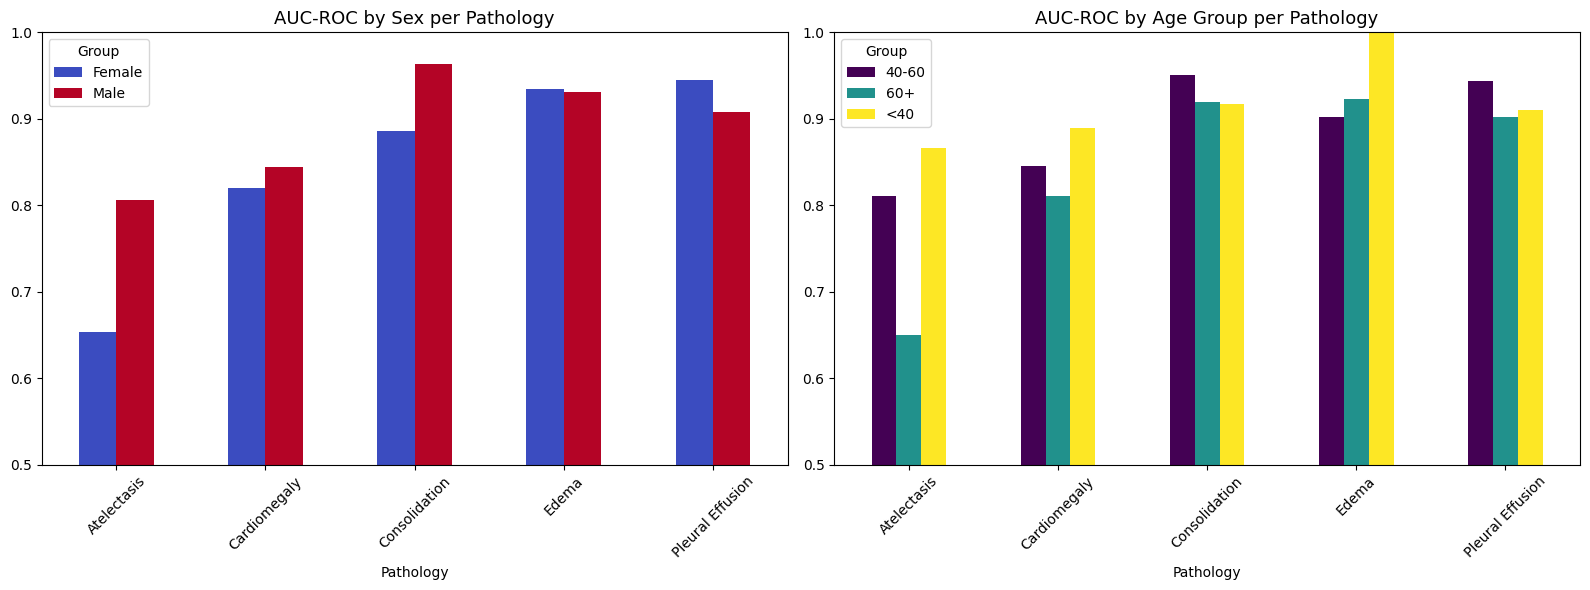

,Pathology,Group,Subgroup_type,AUC-ROC
0,Atelectasis,Male,Sex,0.806566
1,Atelectasis,Female,Sex,0.653741
2,Atelectasis,60+,Age,0.649444
3,Atelectasis,40-60,Age,0.810400
4,Atelectasis,<40,Age,0.866667
5,Cardiomegaly,Male,Sex,0.844075
6,Cardiomegaly,Female,Sex,0.819355
7,Cardiomegaly,60+,Age,0.810685
8,Cardiomegaly,40-60,Age,0.845865
9,Cardiomegaly,<40,Age,0.889423


In [12]:
fairness_analysis(val_df)